In [268]:
import kagglehub

path = kagglehub.dataset_download("jangedoo/utkface-new")
print(path)

/kaggle/input/datasets/jangedoo/utkface-new


In [269]:
import os

for root, dirs, files in os.walk("/kaggle/input/datasets/jangedoo/utkface-new"):
    print(root)

/kaggle/input/datasets/jangedoo/utkface-new
/kaggle/input/datasets/jangedoo/utkface-new/UTKFace
/kaggle/input/datasets/jangedoo/utkface-new/utkface_aligned_cropped
/kaggle/input/datasets/jangedoo/utkface-new/utkface_aligned_cropped/UTKFace
/kaggle/input/datasets/jangedoo/utkface-new/utkface_aligned_cropped/crop_part1
/kaggle/input/datasets/jangedoo/utkface-new/crop_part1


In [270]:
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.layers import *
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.layers import Lambda
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

In [271]:
folder_path="/kaggle/input/datasets/jangedoo/utkface-new/utkface_aligned_cropped/UTKFace"
age=[]
gender=[]
img_path=[]
for file in os.listdir(folder_path):
    age.append(int(file.split('_')[0]))
    gender.append(int(file.split('_')[1]))
    img_path.append(file)

In [272]:
df=pd.DataFrame({'age':age,'gender':gender,'filepath':img_path})
df["filepath"] = df["filepath"].apply(
    lambda x: os.path.join(folder_path, x)
)
df.head()

,age,gender,filepath
0,26,0,/kaggle/input/datasets/jangedoo/utkface-new/ut...
1,22,1,/kaggle/input/datasets/jangedoo/utkface-new/ut...
2,21,1,/kaggle/input/datasets/jangedoo/utkface-new/ut...
3,28,0,/kaggle/input/datasets/jangedoo/utkface-new/ut...
4,17,1,/kaggle/input/datasets/jangedoo/utkface-new/ut...


In [273]:
convo_base=VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)
convo_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_22 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [274]:
# split data inot train test split
from sklearn.model_selection import train_test_split
train_ds, test_ds = train_test_split(df, test_size=0.2, random_state=42)
train_ds, val_ds = train_test_split(train_ds, test_size=0.2, random_state=42)

In [275]:
IMG_SIZE = 224

def load_image(path, age, gender):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))

    return img, {
        "age": tf.cast(age, tf.float32),
        "gender": tf.cast(gender, tf.float32)
    }

train_ds = tf.data.Dataset.from_tensor_slices((
    train_ds["filepath"].values,
    train_ds["age"].values,
    train_ds["gender"].values
))

train_ds = (
    train_ds
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(1000)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = tf.data.Dataset.from_tensor_slices((
    val_ds["filepath"].values,
    val_ds["age"].values,
    val_ds["gender"].values
))

val_ds = (
    val_ds
    .map(load_image)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)
test_ds = tf.data.Dataset.from_tensor_slices((
    test_ds["filepath"].values,
    test_ds["age"].values,
    test_ds["gender"].values
))

test_ds = (
    test_ds
    .map(load_image)
    .batch(32)
    .prefetch(tf.data.AUTOTUNE)
)

In [276]:
# Pretrained model
conv_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze/unfreeze layers as desired
conv_base.trainable = False

# Data augmentation
data_augmentation = tf.keras.Sequential([
    RandomRotation(15 / 360),
    RandomTranslation(0.1, 0.1),
    RandomFlip("horizontal")
])

# Input
inputs = Input(shape=(224, 224, 3))

# Preprocessing
x = Lambda(preprocess_input)(inputs)

# Data augmentation
x = data_augmentation(x)

# VGG16
x = conv_base(x)

# Flatten
x = Flatten()(x)

# ---------- Age branch ----------
age = Dense(512, activation="relu")(x)
age = Dense(512, activation="relu")(age)
age_output = Dense(1, activation="linear", name="age")(age)

# ---------- Gender branch ----------
gender = Dense(512, activation="relu")(x)
gender = Dense(512, activation="relu")(gender)
gender_output = Dense(1, activation="sigmoid", name="gender")(gender)

# Functional model
model = Model(
    inputs=inputs,
    outputs=[age_output, gender_output]
)

model.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_24      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_5 (Lambda)   │ (None, 224, 224,  │          0 │ input_layer_24[0… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_7        │ (None, 224, 224,  │          0 │ lambda_5[0][0]    │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 7, 7, 512) │ 14,714,688 │ sequential_7[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 25088)     │          0 │ vgg16[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 512)       │ 12,845,568 │ flatten_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 512)       │ 12,845,568 │ flatten_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 512)       │    262,656 │ dense_18[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 512)       │    262,656 │ dense_20[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age (Dense)         │ (None, 1)         │        513 │ dense_19[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender (Dense)      │ (None, 1)         │        513 │ dense_21[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 40,932,162 (156.14 MB)

 Trainable params: 26,217,474 (100.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [277]:
#Early stopping
import tensorflow.keras.callbacks as callbacks
early_stopping =  callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0.001, # minimium amount of change to count as an improvement
    patience=10, # how many epochs to wait before stopping
    restore_best_weights=True,
    verbose=1,
)


In [278]:
model.compile(
    optimizer='adam',
    loss={
        "age": "mse",
        "gender": "binary_crossentropy"
    },
    metrics={
        "age": "mae",
        "gender": "accuracy"
    }
)

In [279]:
# train model
import tensorflow as tf
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max"
)
model_history=model.fit(train_ds, epochs=15, validation_data=val_ds,callbacks=[early_stopping,checkpoint])

Epoch 1/15
475/475 ━━━━━━━━━━━━━━━━━━━━ 89s 180ms/step - age_loss: 252.6541 - age_mae: 10.1373 - gender_accuracy: 0.8149 - gender_loss: 0.6912 - loss: 253.7721 - val_age_loss: 138.2695 - val_age_mae: 8.6747 - val_gender_accuracy: 0.8782 - val_gender_loss: 0.3010 - val_loss: 138.6757
Epoch 2/15
475/475 ━━━━━━━━━━━━━━━━━━━━ 93s 194ms/step - age_loss: 135.1804 - age_mae: 8.5347 - gender_accuracy: 0.8604 - gender_loss: 0.3359 - loss: 135.5870 - val_age_loss: 123.7783 - val_age_mae: 8.0092 - val_gender_accuracy: 0.8832 - val_gender_loss: 0.2799 - val_loss: 124.0661
Epoch 3/15
475/475 ━━━━━━━━━━━━━━━━━━━━ 99s 206ms/step - age_loss: 116.1690 - age_mae: 7.8959 - gender_accuracy: 0.8694 - gender_loss: 0.3107 - loss: 116.5228 - val_age_loss: 118.4857 - val_age_mae: 7.8966 - val_gender_accuracy: 0.8890 - val_gender_loss: 0.2776 - val_loss: 118.5993
Epoch 4/15
475/475 ━━━━━━━━━━━━━━━━━━━━ 96s 201ms/step - age_loss: 109.5706 - age_mae: 7.6251 - gender_accuracy: 0.8770 - gender_loss: 0.2997 - loss: 

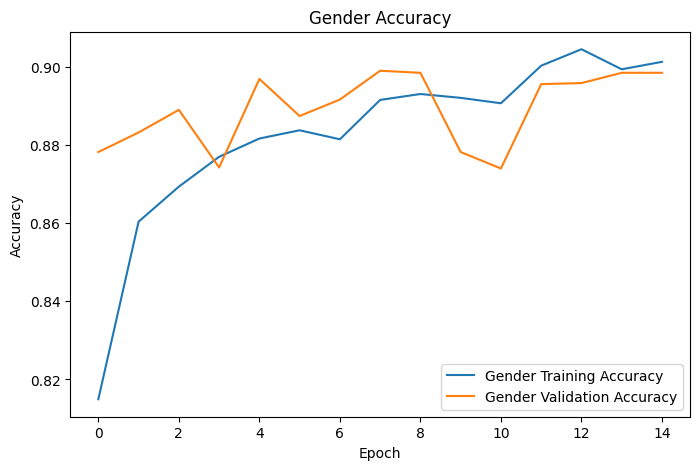

In [280]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.plot(model_history.history['gender_accuracy'],label='Gender Training Accuracy')
plt.plot(model_history.history['val_gender_accuracy'],label='Gender Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Gender Accuracy")
plt.legend()
plt.show()

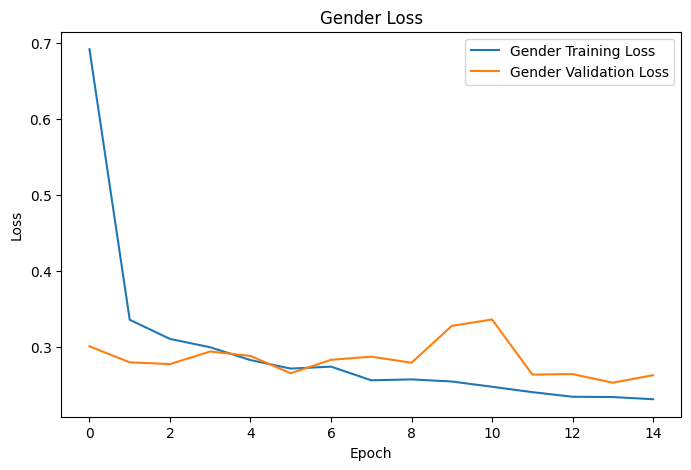

In [281]:
plt.figure(figsize=(8,5))

plt.plot(model_history.history['gender_loss'],label='Gender Training Loss')
plt.plot(model_history.history['val_gender_loss'],label='Gender Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Gender Loss")
plt.legend()
plt.show()

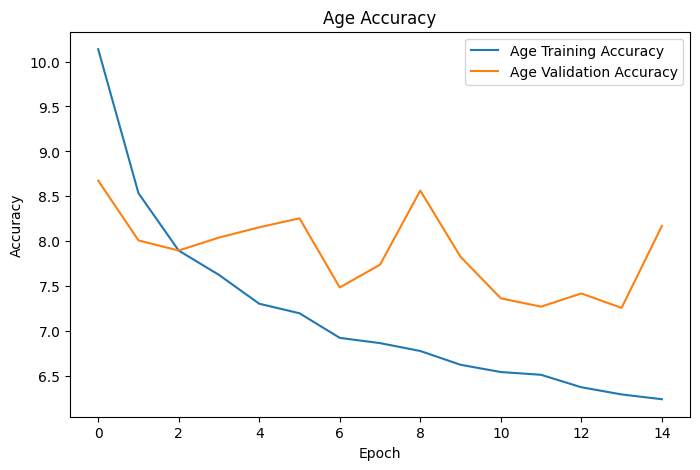

In [282]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.plot(model_history.history['age_mae'],label='Age Training Accuracy')
plt.plot(model_history.history['val_age_mae'],label='Age Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Age Accuracy")
plt.legend()
plt.show()

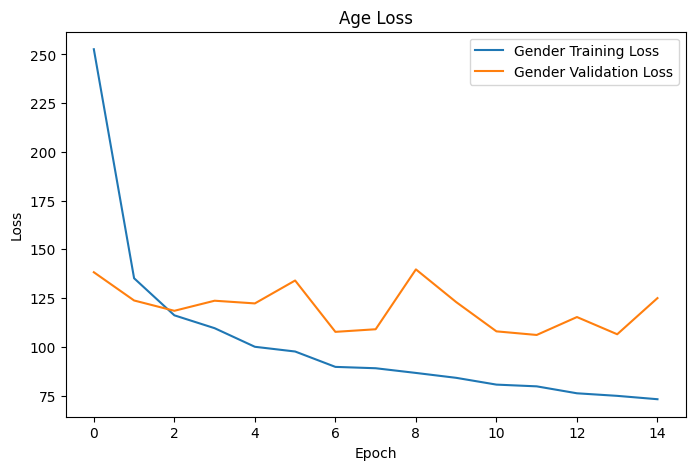

In [283]:
plt.figure(figsize=(8,5))

plt.plot(model_history.history['age_loss'],label='Gender Training Loss')
plt.plot(model_history.history['val_age_loss'],label='Gender Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Age Loss")
plt.legend()
plt.show()

In [284]:
predictions = model.predict(test_ds)

age_pred = predictions[0]
gender_pred = predictions[1]
gender_pred = (gender_pred > 0.5).astype(int)

149/149 ━━━━━━━━━━━━━━━━━━━━ 21s 143ms/step


In [291]:
# predict output
import pandas as pd 
import numpy as np

true_age = []
true_gender = []
images_list=[]
predictions[0]
for image,labels in test_ds:
    true_age.extend(labels['age'].numpy())
    true_gender.extend(labels['gender'].numpy())
    images_list.extend(image)
true_age=np.array(true_age)
true_gender=np.array(true_gender)
images_list = np.array(images_list)

print("Actual Age :",true_age[1])
print("Predicted Age:",age_pred[1][0])

print("Actual Gender :",true_gender[1])

print("Predicted Gender:",gender_pred[1][0])


Actual Age : 24.0
Predicted Age: 27.510906
Actual Gender : 1.0
Predicted Gender: 1


In [292]:
from sklearn.metrics import ConfusionMatrixDisplay,classification_report
print(classification_report(true_gender,gender_pred))

              precision    recall  f1-score   support

         0.0       0.91      0.88      0.90      2500
         1.0       0.87      0.90      0.89      2242

    accuracy                           0.89      4742
   macro avg       0.89      0.89      0.89      4742
weighted avg       0.89      0.89      0.89      4742



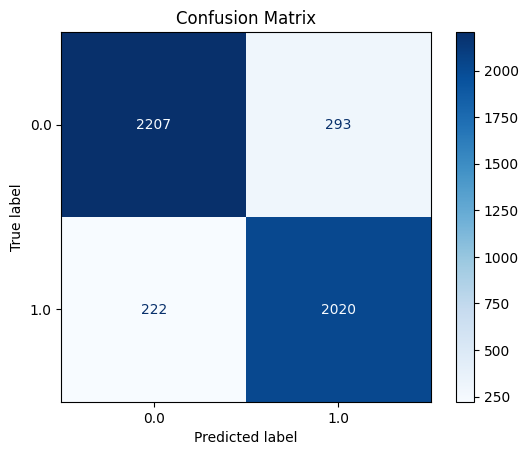

In [293]:
# print confusion matrix

ConfusionMatrixDisplay.from_predictions(
   true_gender,gender_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

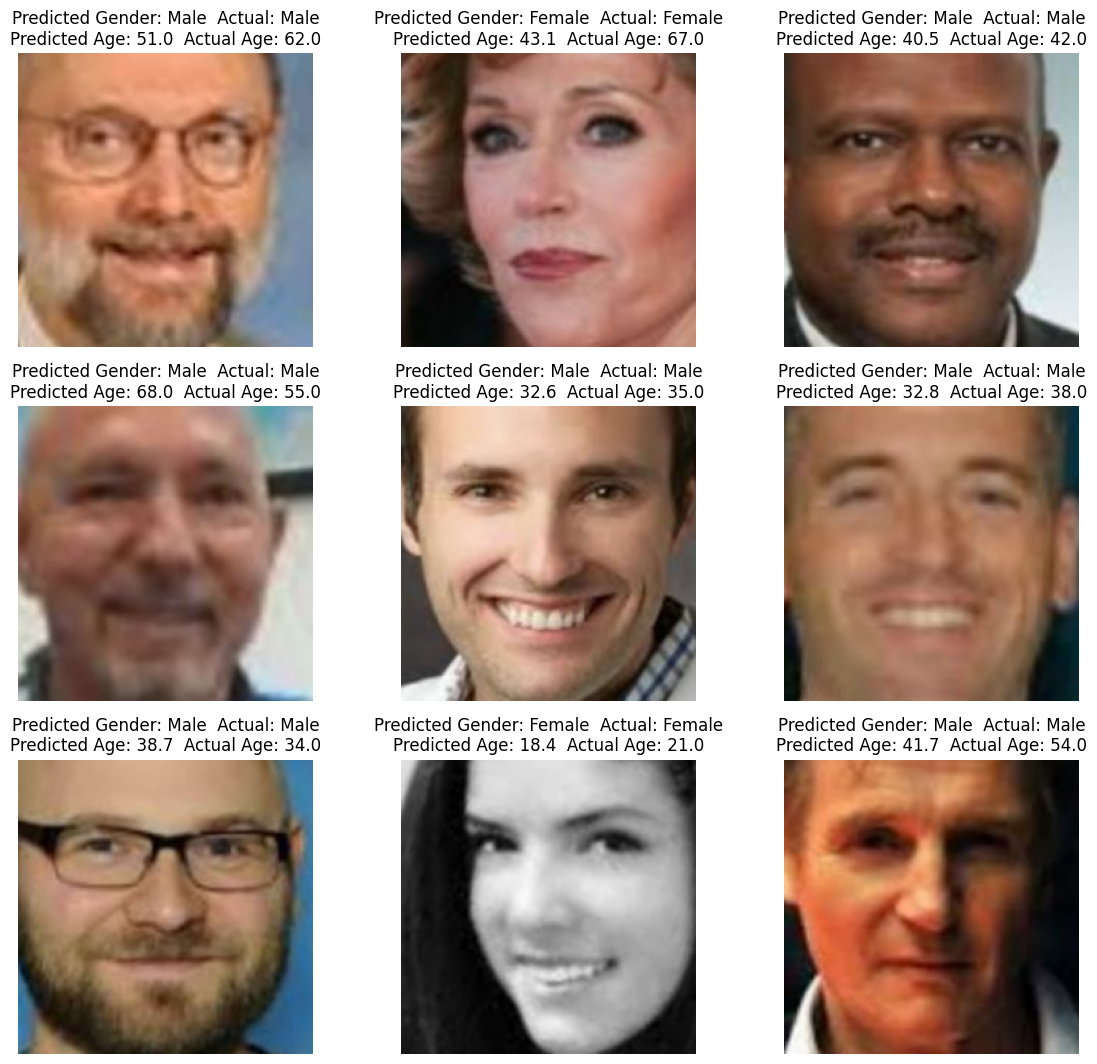

In [296]:
import matplotlib.pyplot as plt
import numpy as np

gender_map = {
    0: "Male",
    1: "Female"
}

plt.figure(figsize=(14,13))

for i in range(9):
    index = np.random.randint(len(images_list))

    plt.subplot(3,3,i+1)
    plt.imshow(images_list[index].astype("uint8"))

    plt.title(
        f"Predicted Gender: {gender_map[gender_pred[index][0]]}" f"  "
        f"Actual: {gender_map[true_gender[index]]}" "\n"
          f"Predicted Age: {age_pred[index][0]:.1f}" f"  "
        f"Actual Age: {true_age[index]:.1f}" 
    )

    plt.axis("off")

plt.show()

In [297]:
import os
print(os.listdir())

['.virtual_documents', 'pretained_VGG-model.keras', 'best_model.keras']


In [298]:
from IPython.display import FileLink

FileLink("best_model.keras")

/kaggle/working/best_model.keras